In [1]:
from logicqubit.logic import *
from openfermion.chem import MolecularData
from openfermion.transforms import get_fermion_operator, jordan_wigner, bravyi_kitaev, parity_code
from openfermion.linalg import get_ground_state, get_sparse_operator
from openfermionpyscf import run_pyscf
from cmath import *
import numpy as np
import scipy
from scipy.optimize import *
import matplotlib.pyplot as plt

logicqubit version 1.7.9


https://arxiv.org/abs/1304.3061

10.1103/PhysRevX.6.031007

Second Quantized Hamiltonian
\begin{eqnarray*}
    \mathcal{H}(r)=h_0 + \sum_{pq} h_{pq}(r) a^{\dagger}_p a_q +\frac{1}{2} \sum_{pqrs} h_{pqrs}(r) a^{\dagger}_p a^{\dagger}_qa_ra_s
\end{eqnarray*}

\begin{eqnarray*}
    h_{pq}(r)=\int{d\mathbf{r}}\,\phi^*_p(\mathbf{r})\left(-\frac{1}{2}\nabla^2-\sum_{a}{\frac{Z_a}{\mathbf{r}_{a,\mathbf{r}}}}\right)\phi_q(\mathbf{r})
\end{eqnarray*}

\begin{eqnarray*}
    h_{pqrs}(r)=\int{d\mathbf{r_1}\,d\mathbf{r_2}}\,\phi^*_p(\mathbf{r_1})\phi^*_q(\mathbf{r_2})r_{1,2}^{-1}\phi_r(\mathbf{r_1})\phi_s(\mathbf{r_2})
\end{eqnarray*}

Jordan-Wigner transformation
\begin{eqnarray*}
    a^{\dagger} = I^{\otimes j-1}\otimes \sigma_{-} \otimes \sigma_{z}^{\otimes N-j}\\
    a = I^{\otimes j-1}\otimes \sigma_{+} \otimes \sigma_{z}^{\otimes N-j}
\end{eqnarray*}

In [5]:
gates = Gates(1)

ID = gates.ID()
X = gates.X()
Y = gates.Y()
Z = gates.Z()

In [6]:
def ansatz(reg, params):
    n_qubits = len(reg)
    depth = n_qubits
    for i in range(depth):
        for j in range(n_qubits):
            if(j < n_qubits-1):
                reg[j+1].CNOT(reg[j])
            reg[i].RY(params[j])
            
def ansatz_4q16(q1, q2, q3, q4, params):
    q1.RY(params[0])
    q2.RY(params[1])
    q3.RY(params[2])
    q4.RY(params[3])
    q2.CNOT(q1)
    q3.CNOT(q2)
    q4.CNOT(q3)
    q1.RY(params[4])
    q2.RY(params[5])
    q3.RY(params[6])
    q4.RY(params[7])
    q2.CNOT(q1)
    q3.CNOT(q2)
    q4.CNOT(q3)
    q1.RY(params[8])
    q2.RY(params[9])
    q3.RY(params[10])
    q4.RY(params[11])
    q2.CNOT(q1)
    q3.CNOT(q2)
    q4.CNOT(q3)
    q1.RY(params[12])
    q2.RY(params[13])
    q3.RY(params[14])
    q4.RY(params[15])
    q2.CNOT(q1)
    q3.CNOT(q2)
    q4.CNOT(q3)
    
def ansatz_4q1(q0, q1, q2, q3, params):
    q0.X()
    q1.RY(params[0])
    q0.CNOT(q1)
    q2.CNOT(q0)
    q3.CNOT(q1)

def ansatz_4q2(q1, q2, q3, q4, params):
    q1.X()
    q1.RY(params[0])
    q2.RY(params[1])
    q1.CNOT(q2)
    q3.CNOT(q1)
    q4.CNOT(q2)
    
def ansatz_4q4(q1, q2, q3, q4, params):
    q1.RY(params[0])
    q2.RZ(params[1])
    q3.RY(params[2])
    q4.RZ(params[3])
    q2.CNOT(q1)
    q3.CNOT(q2)
    q4.CNOT(q3)

Repulsion energy (Eh): 0.7055696793059831


/tmp/ipykernel_42851/1317428000.py:237: OptimizeWarning: Unknown solver options: xtol
  minimum = minimize(


Distance = 0.3000, Error = 3.074307e-07, Energy = -0.6018034033
Distance = 0.3564, Error = 2.733701e-08, Energy = -0.8081934877
Distance = 0.4128, Error = 7.482430e-09, Energy = -0.9389927732
Distance = 0.4692, Error = 4.250347e-06, Energy = -1.0229632797
Distance = 0.5256, Error = 4.155652e-09, Energy = -1.0763898611
Distance = 0.5821, Error = 2.177350e-09, Energy = -1.1091181791
Distance = 0.6385, Error = 4.206190e-06, Energy = -1.1274935775
Distance = 0.6949, Error = 1.828677e-07, Energy = -1.1358199705
Distance = 0.7513, Error = 3.682944e-09, Energy = -1.1370842881
Distance = 0.8077, Error = 1.319109e-09, Energy = -1.1334180061
Distance = 0.8641, Error = 7.934358e-09, Energy = -1.1263364734
Distance = 0.9205, Error = 3.979668e-07, Energy = -1.1169202607
Distance = 0.9769, Error = 1.605994e-06, Energy = -1.1059474904
Distance = 1.0333, Error = 5.908167e-08, Energy = -1.0939952570
Distance = 1.0897, Error = 1.012132e-07, Energy = -1.0814959707
Distance = 1.1462, Error = 1.608465e-07,

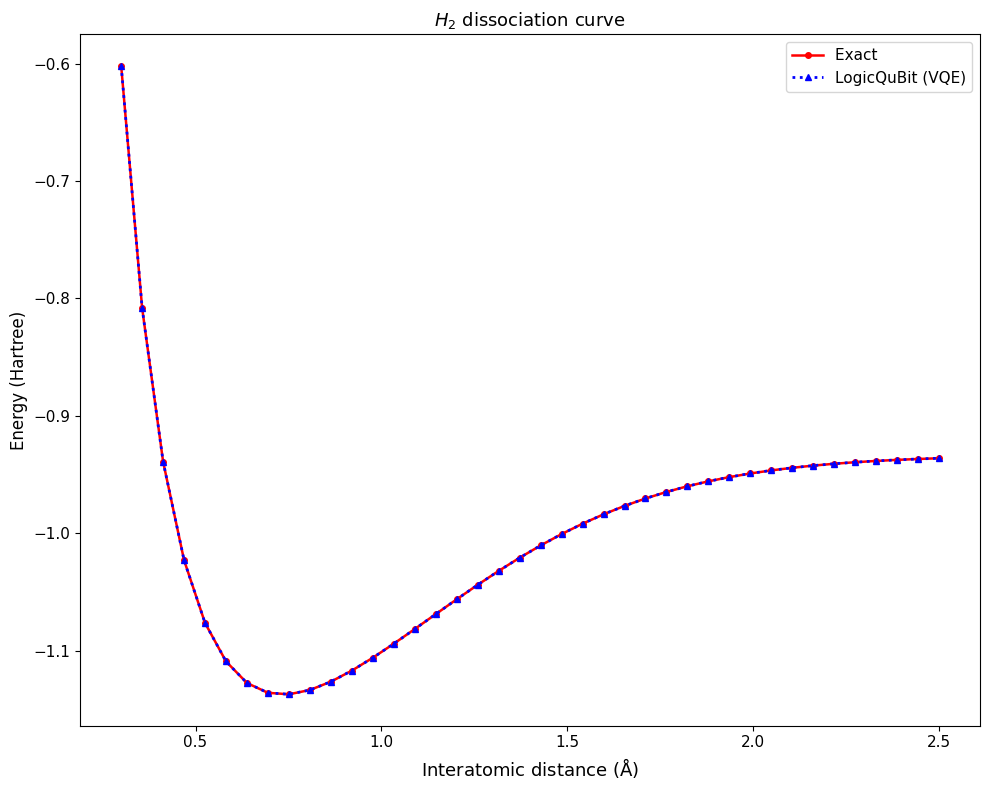

In [8]:
def get_molecule(distance = 0.75):
    geometry = [('H', (0., 0., 0.)), ('H', (0., 0., distance))]
    basis = "sto-3g"
    multiplicity = 1
    charge = 0
    description = "H2"

    molecule_h2 = MolecularData(geometry, basis, multiplicity, charge, description)
    molecule_h2 = run_pyscf(molecule_h2, run_scf=1, verbose=0)

    # nuclear repulsion já incluída
    molecule_h2 = jordan_wigner(get_fermion_operator(molecule_h2.get_molecular_hamiltonian()))

    mol_gates = list(molecule_h2.terms.keys())
    mol_co = list(molecule_h2.terms.values())
    return mol_gates, mol_co

def get_sigma(gate_name):
    if gate_name == 'X':
        gate = X
    elif gate_name == 'Y':
        gate = Y
    elif gate_name == 'Z':
        gate = Z
    else:
        gate = ID
    return gate

def get_H_k(mol_gates):
    gate_list = []
    name_list = []
    for pauli_gate in mol_gates:
        prod_list = [get_sigma('I') for _ in range(4)]
        name_gate_list = ['I' for _ in range(4)]
        for term in pauli_gate:
            prod_list[3-term[0]] = get_sigma(term[1])
            name_gate_list[3-term[0]] = term[1]
        gate_kron = prod_list[0]
        for item in prod_list[1:]:
            gate_kron = gate_kron.kron(item)
        gate_list.append(gate_kron)
        name_list.append(name_gate_list)
    return gate_list, name_list

def get_base(mol_gate):
    prod_list = [Matrix([1, 1]) for _ in range(4)]
    if isinstance(mol_gate, tuple):
        for item in mol_gate:
            prod_list[3-item[0]] = Matrix([1, -1])
    else:
        gate_list = list(mol_gate)
        for i, item in enumerate(gate_list):
            if item != 'I':
                prod_list[i] = Matrix([1, -1])
    base_kron = prod_list[0]
    for item in prod_list[1:]:
        base_kron = base_kron.kron(item)
    return base_kron

def sum(items):
    value = items[0]
    for item in items[1:]:
        value = value + item
    return value

def repulsion_energy(Z1=1, Z2=1, r=75e-12):
    Eh = 4.3597447222071e-18
    ep0 = 8.854187e-12
    e = -1.602176634e-19
    return (1/(4*pi*ep0)*(Z1*Z2*e**2)/r)/Eh

rep_energy = repulsion_energy()
print("Repulsion energy (Eh): %s" % rep_energy)

def expectation_value(measurements, base=np.array([ 1, -1, -1,  1, -1,  1,  1, -1,
                                                   -1,  1,  1, -1,  1, -1, -1,  1])):
    probabilities = np.array(measurements)
    expectation = np.sum(base * probabilities)
    return expectation.real

def sigma_zzzz(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    result = logicQuBit.Measure([q1, q2, q3, q4])

    iiiz = expectation_value(result, get_base('IIIZ').get())
    iizi = expectation_value(result, get_base('IIZI').get())
    izii = expectation_value(result, get_base('IZII').get())
    ziii = expectation_value(result, get_base('ZIII').get())
    iizz = expectation_value(result, get_base('IIZZ').get())

    iziz = expectation_value(result, get_base('IZIZ').get())
    ziiz = expectation_value(result, get_base('ZIIZ').get())
    izzi = expectation_value(result, get_base('IZZI').get())
    zizi = expectation_value(result, get_base('ZIZI').get())
    zzii = expectation_value(result, get_base('ZZII').get())

    return iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii

def sigma_yxxy(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    # medidas em X
    q2.RY(-pi/2)
    q3.RY(-pi/2)

    # medidas em Y
    q1.RX(pi/2)
    q4.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def sigma_xyyx(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    # medidas em X
    q1.RY(-pi/2)
    q4.RY(-pi/2)

    # medidas em Y
    q2.RX(pi/2)
    q3.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def sigma_xxyy(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    # medidas em X
    q1.RY(-pi/2)
    q2.RY(-pi/2)

    # medidas em Y
    q3.RX(pi/2)
    q4.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def sigma_yyxx(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    # medidas em X
    q3.RY(-pi/2)
    q4.RY(-pi/2)

    # medidas em Y
    q1.RX(pi/2)
    q2.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def pauli_name(pauli_gate):
    name = ['I'] * 4
    for qubit, op in pauli_gate:
        name[3-qubit] = op
    return ''.join(name)

def expectation_energy(params, co_dict):
    iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii = sigma_zzzz(params)
    yxxy = sigma_yxxy(params)
    xyyx = sigma_xyyx(params)
    xxyy = sigma_xxyy(params)
    yyxx = sigma_yyxx(params)

    result = (
        co_dict.get('IIII', 0.0)
        + co_dict.get('IIIZ', 0.0) * iiiz
        + co_dict.get('IIZI', 0.0) * iizi
        + co_dict.get('IZII', 0.0) * izii
        + co_dict.get('ZIII', 0.0) * ziii
        + co_dict.get('IIZZ', 0.0) * iizz
        + co_dict.get('YXXY', 0.0) * yxxy
        + co_dict.get('XYYX', 0.0) * xyyx
        + co_dict.get('XXYY', 0.0) * xxyy
        + co_dict.get('YYXX', 0.0) * yyxx
        + co_dict.get('IZIZ', 0.0) * iziz
        + co_dict.get('ZIIZ', 0.0) * ziiz
        + co_dict.get('IZZI', 0.0) * izzi
        + co_dict.get('ZIZI', 0.0) * zizi
        + co_dict.get('ZZII', 0.0) * zzii
    )
    return result

n = 40
distances = np.linspace(0.3, 2.5, n)
exact_energy = []
energies = []
initial_values = np.random.uniform(-np.pi, np.pi, 4)

for i, distance in enumerate(distances):

    mol_gates, mol_co = get_molecule(distance)
    co = [c.real for c in mol_co]
    co_dict = {pauli_name(g): c.real for g, c in zip(mol_gates, mol_co)}

    H = sum([gate * coef for gate, coef in zip(get_H_k(mol_gates)[0], mol_co)])
    exact_energy.append(min(scipy.linalg.eig(H.get())[0]).real)

    minimum = minimize(
        expectation_energy,
        initial_values,
        method='SLSQP',
        options={'xtol': 1e-5, 'ftol': 1e-5},
        args=(co_dict,)
    )
    energies.append(minimum.fun)

    print(f"Distance = {distance:.4f}, Error = {abs(minimum.fun - exact_energy[-1]):.6e}, Energy = {minimum.fun:.10f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.plot(distances, exact_energy, color='red', linestyle='-', marker='o', markersize=4, linewidth=1.8, label='Exact ')
ax.plot(distances, energies, color='blue', linestyle=':', marker='^', markersize=4, linewidth=2.0, label='LogicQuBit (VQE)')
ax.set_xlabel(r'Interatomic distance ($\mathrm{\AA}$)', fontsize=13)
ax.set_ylabel('Energy (Hartree)', fontsize=12)
ax.set_title(r'$H_2$ dissociation curve', fontsize=13)
ax.legend(fontsize=11, frameon=True)
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()

In [9]:
def expectation_4q(params):
    logicQuBit  = LogicQuBit(4)
    q0 = Qubit()
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    
    ansatz_4q4(q0,q1,q2,q3,params)
    psi = logicQuBit.getPsi()
    
    return (psi.adjoint()*H*psi).get()[0][0].real

initial_values = np.random.uniform(-np.pi, np.pi, 4)
minimum = minimize(expectation_4q, initial_values, method='SLSQP',options={'xtol': 1e-5, 'ftol': 1e-5})
print(minimum.fun)

-0.936054771314548


/tmp/ipykernel_42851/1177745638.py:14: OptimizeWarning: Unknown solver options: xtol
  minimum = minimize(expectation_4q, initial_values, method='SLSQP',options={'xtol': 1e-5, 'ftol': 1e-5})


In [10]:
mol_gates, mol_co = get_molecule(0.75)
co = [c.real for c in mol_co]
H_k = get_H_k(mol_gates)
H = sum([gate*co for gate,co in zip(H_k[0], mol_co)])
min(scipy.linalg.eig(H.get())[0])

np.complex128(-1.137117067345731+0j)

Distance = 0.3000 | Exact = -0.6018037108 | VQE = -0.6018035229 | Error = 1.879151e-07
Distance = 0.3564 | Exact = -0.8081935151 | VQE = -0.8081933400 | Error = 1.751043e-07
Distance = 0.4128 | Exact = -0.9389927807 | VQE = -0.9389925936 | Error = 1.870432e-07
Distance = 0.4692 | Exact = -1.0229675300 | VQE = -1.0229673128 | Error = 2.171838e-07
Distance = 0.5256 | Exact = -1.0763898653 | VQE = -1.0763896017 | Error = 2.636084e-07
Distance = 0.5821 | Exact = -1.1091181813 | VQE = -1.1091178562 | Error = 3.251120e-07
Distance = 0.6385 | Exact = -1.1274977837 | VQE = -1.1274974635 | Error = 3.201791e-07
Distance = 0.6949 | Exact = -1.1358201534 | VQE = -1.1358197605 | Error = 3.928662e-07
Distance = 0.7513 | Exact = -1.1370842918 | VQE = -1.1370839040 | Error = 3.878107e-07
Distance = 0.8077 | Exact = -1.1334180074 | VQE = -1.1334175555 | Error = 4.519397e-07
Distance = 0.8641 | Exact = -1.1263364814 | VQE = -1.1263359757 | Error = 5.056947e-07
Distance = 0.9205 | Exact = -1.1169206586 |

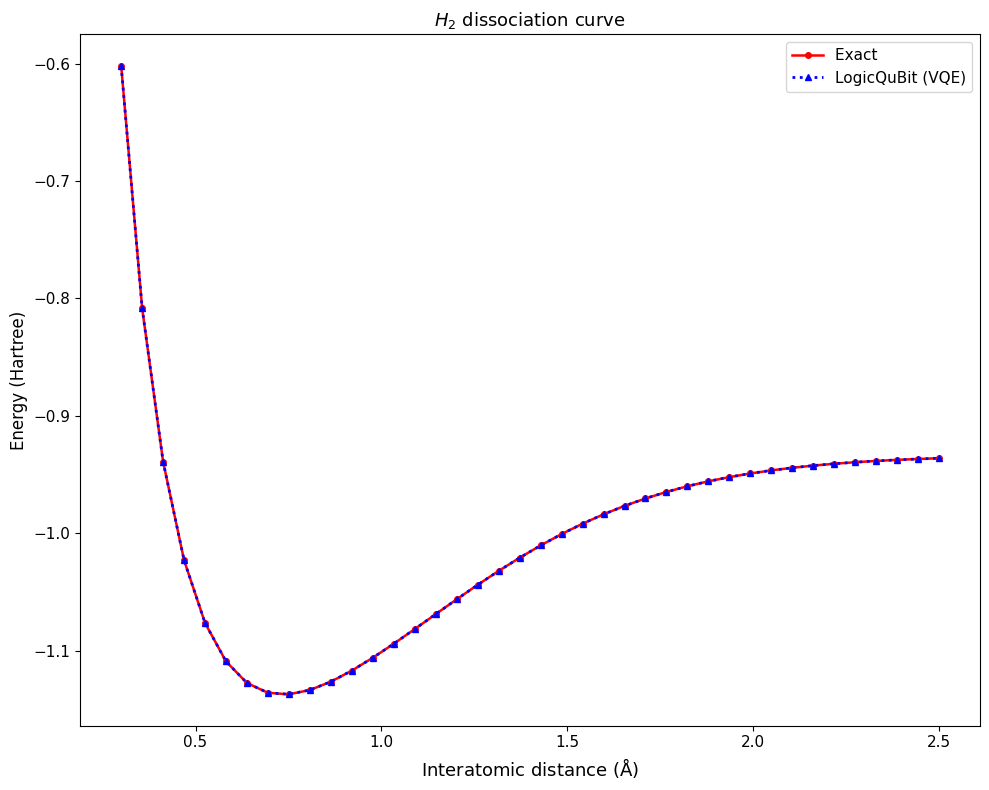

In [108]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

def gradient(params, evaluate, args):
    n_params = params.shape[0]
    shift = np.pi / 2
    gradients = np.zeros(n_params)
    
    for i in range(n_params):
        #parameter shift rule
        shift_vect = np.array([shift if j==i else 0 for j in range(n_params)])
        shift_right = params + shift_vect
        shift_left = params - shift_vect
        
        expectation_right = evaluate(shift_right, args)
        expectation_left = evaluate(shift_left, args)

        gradients[i] = 0.5 * (expectation_right - expectation_left)

    return gradients

def optimize_energy(co, distance, params, lr=0.1, tol=1e-4, max_iter=1000):
    params = np.array(params, dtype=float).copy()
    last_params = np.zeros(4)

    err = 1
    it = 0
    while err > tol and it < max_iter:
        grad = gradient(params, expectation_energy, co)
        params = params - lr * grad

        err = np.linalg.norm(params - last_params)
        last_params = np.array(params)
        it += 1

    energy = expectation_energy(params, co)
    return energy
    
n = 40
distances = np.linspace(0.3, 2.5, n)

exact_energy = []
energies = []
initial_params = np.random.uniform(-np.pi, np.pi, 4)

for i, distance in enumerate(distances):

    mol_gates, mol_co = get_molecule(distance)
    co_dict = {pauli_name(g): c.real for g, c in zip(mol_gates, mol_co)}

    H = sum([gate * coef for gate, coef in zip(get_H_k(mol_gates)[0], mol_co)])
    exact_e = scipy.linalg.eigvalsh(H.get())[0].real
    exact_energy.append(exact_e)

    energy = optimize_energy(co_dict, distance, initial_params)
    energies.append(energy)

    print(
        f"Distance = {distance:.4f} | "
        f"Exact = {exact_e:.10f} | "
        f"VQE = {energy:.10f} | Error = {abs(energy - exact_e):.6e}"
    )

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.plot(distances, exact_energy, color='red', linestyle='-', marker='o', markersize=4, linewidth=1.8, label='Exact ')
ax.plot(distances, energies, color='blue', linestyle=':', marker='^', markersize=4, linewidth=2.0, label='LogicQuBit (VQE)')

ax.set_xlabel(r'Interatomic distance ($\mathrm{\AA}$)', fontsize=13)
ax.set_ylabel('Energy (Hartree)', fontsize=12)
ax.set_title(r'$H_2$ dissociation curve', fontsize=13)
ax.legend(fontsize=11, frameon=True)
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.show()